- data source: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
%pwd

'/content'

In [ ]:
!ls -al {path}/chest_xray/val/NORMAL

total 2368
drwxr-sr-x 2 1000 1000      0 Aug 25 18:42 .
drwxr-sr-x 4 1000 1000      0 Aug 25 18:42 ..
-rw-r--r-- 1 1000 1000 253130 Aug 25 18:42 NORMAL2-IM-1427-0001.jpeg
-rw-r--r-- 1 1000 1000 262713 Aug 25 18:42 NORMAL2-IM-1430-0001.jpeg
-rw-r--r-- 1 1000 1000 250393 Aug 25 18:42 NORMAL2-IM-1431-0001.jpeg
-rw-r--r-- 1 1000 1000 248826 Aug 25 18:42 NORMAL2-IM-1436-0001.jpeg
-rw-r--r-- 1 1000 1000 213744 Aug 25 18:42 NORMAL2-IM-1437-0001.jpeg
-rw-r--r-- 1 1000 1000 170888 Aug 25 18:42 NORMAL2-IM-1438-0001.jpeg
-rw-r--r-- 1 1000 1000 530145 Aug 25 18:42 NORMAL2-IM-1440-0001.jpeg
-rw-r--r-- 1 1000 1000 475144 Aug 25 18:42 NORMAL2-IM-1442-0001.jpeg


['PNEUMONIA', 'NORMAL']


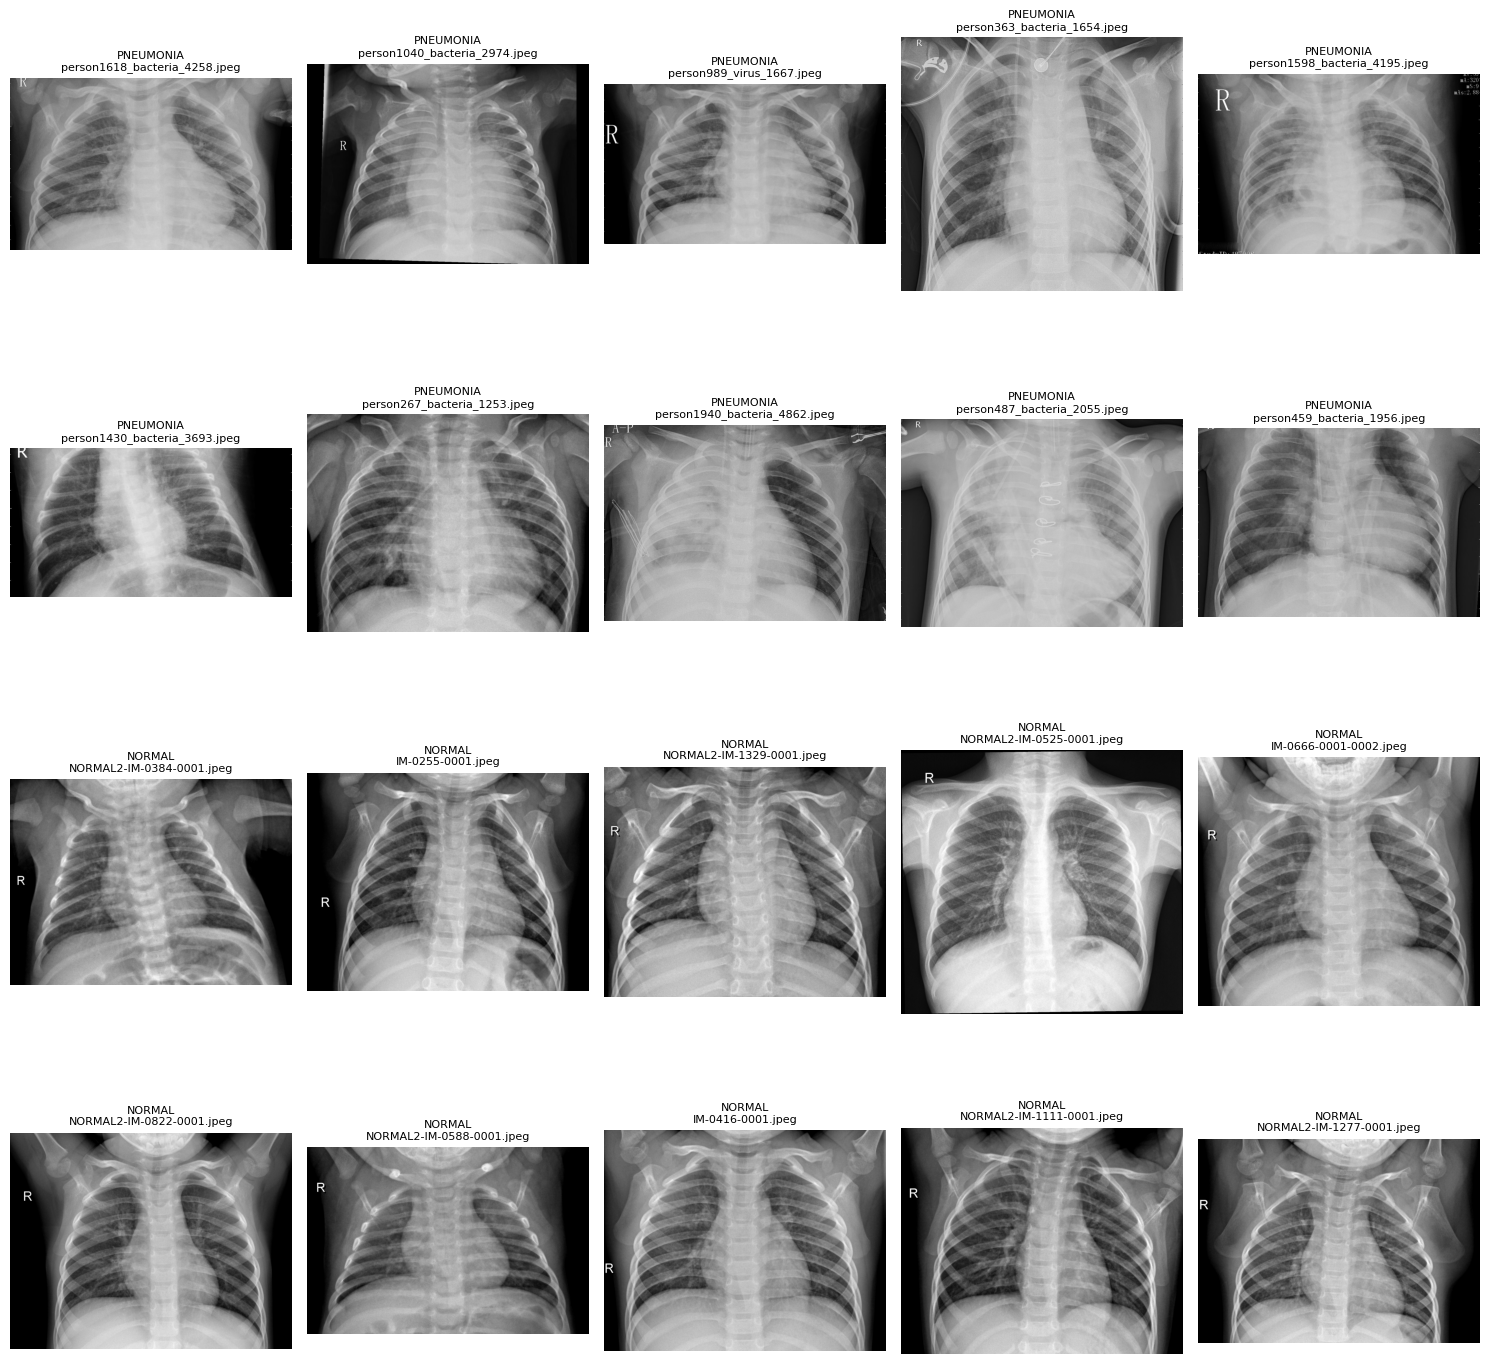

In [ ]:
import os
import numpy as np
import pandas as pd
import random
import PIL
import matplotlib.pyplot as plt
import cv2

import warnings
warnings.filterwarnings('ignore')

# 경로 설정
base_path = path + '/chest_xray/train'

# 클래스 폴더 목록
class_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print( class_folders)

# 클래스별로 10장씩 이미지 추출
selected_images = []

for class_name in class_folders:
    folder_path = os.path.join(base_path, class_name)
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg', '.png'))]
    selected_files = random.sample(all_files, 10)
    for fname in selected_files:
        img_path = os.path.join(folder_path, fname)
        selected_images.append((img_path, class_name, fname))

# 시각화
fig, axs = plt.subplots(4, 5, figsize=(15, 15))
axs = axs.flatten()

for idx, (img_path, class_name, fname) in enumerate(selected_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axs[idx].imshow(img, cmap='gray')
    axs[idx].axis('off')
    axs[idx].set_title(f"{class_name}\n{fname}", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
def Sobel_edge( image):

    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobelx**2 + sobely**2)
    sobel = cv2.convertScaleAbs(sobel).astype(np.uint8)
    return sobel


def Canny_edge(image):
    canny = cv2.Canny(image, 50, 150)
    canny = cv2.normalize(canny, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return canny


def FFT_2D(image):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    mag = np.log(np.abs(fshift)+1)
    mag_uint8 = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return mag_uint8



def my_preprocessing(image):
    import cv2
    import numpy as np
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Ensure grayscale image is uint8 for Canny
    gray_uint8 = gray.astype(np.uint8)

    sobel = Sobel_edge( gray_uint8)
    canny = Canny_edge( gray_uint8)
    mag = FFT_2D( gray_uint8)
    dst = np.stack([gray, mag, canny], axis = -1)
    return dst

Found 5216 images belonging to 2 classes.


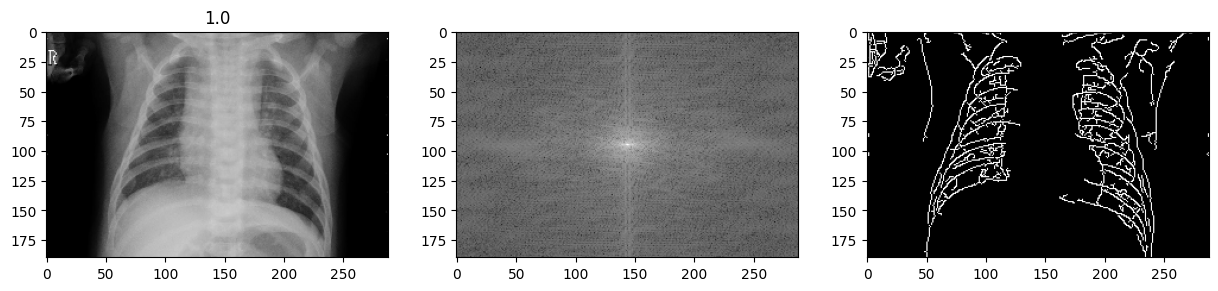

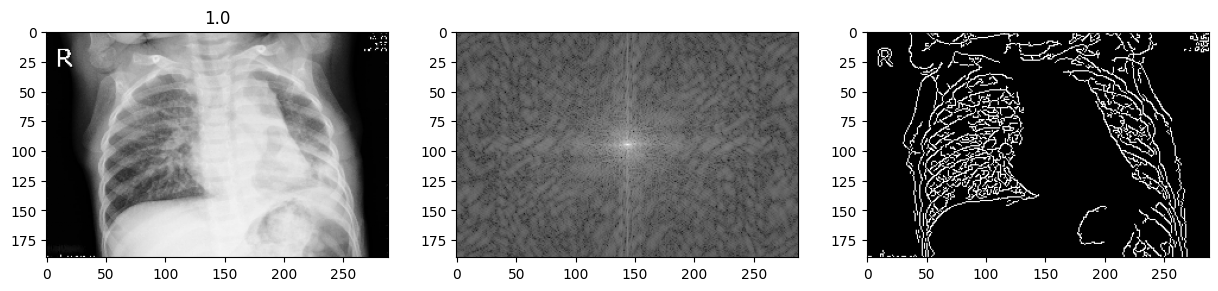

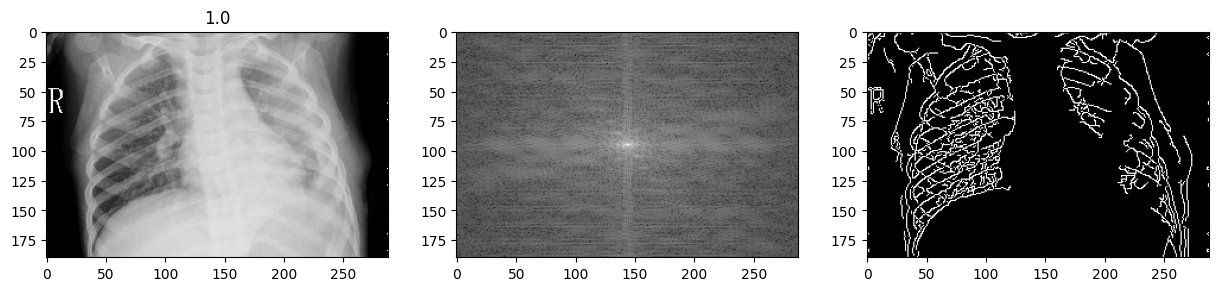

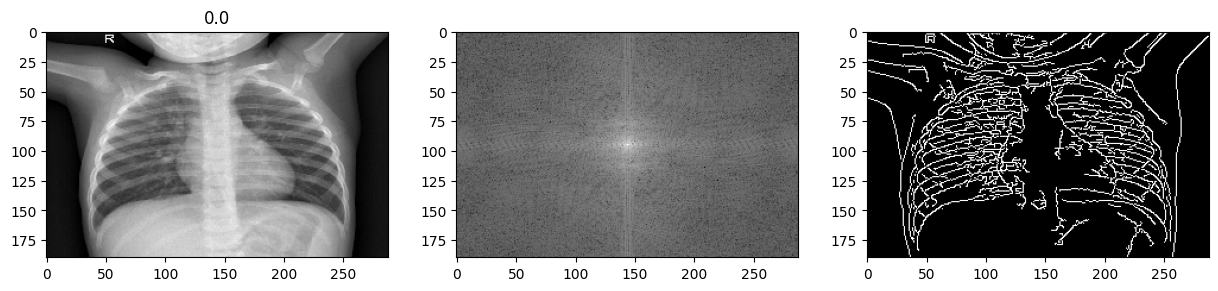

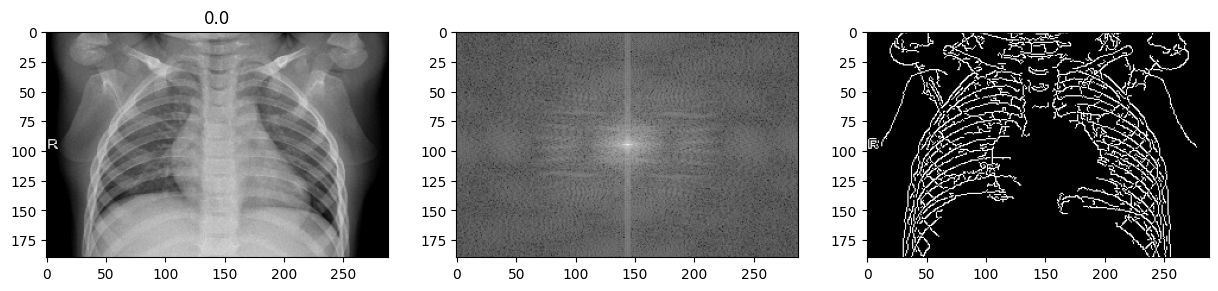

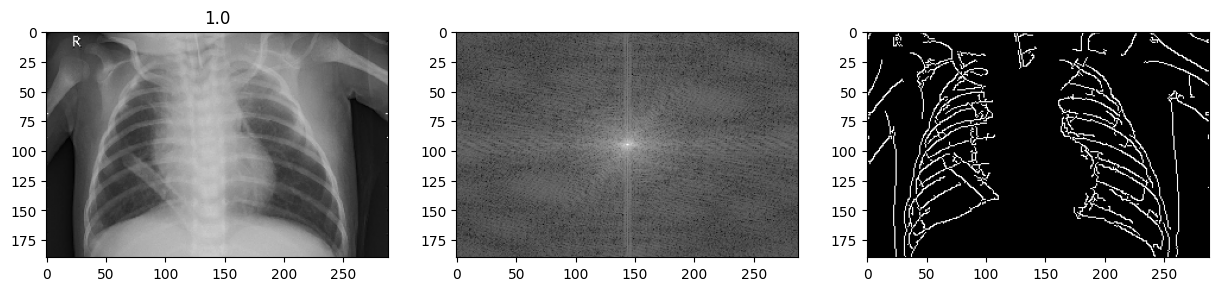

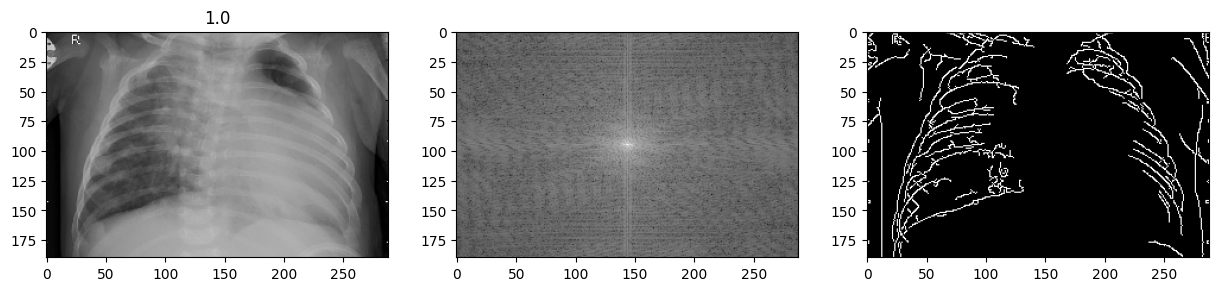

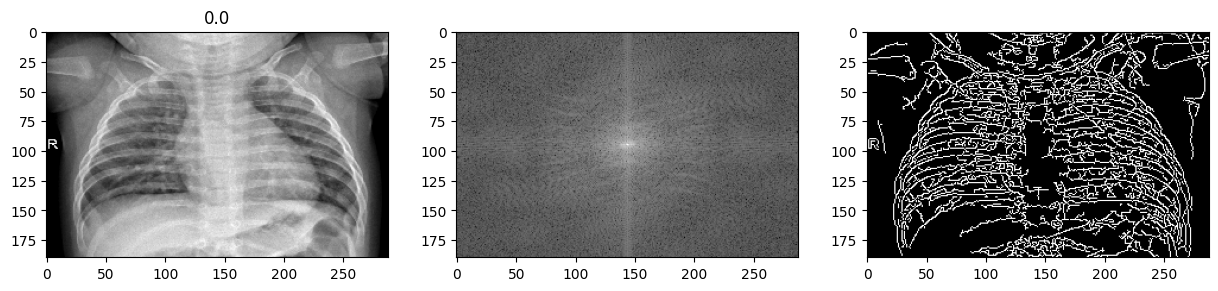

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = path + '/chest_xray/train'
training_generator = ImageDataGenerator(preprocessing_function=my_preprocessing   )  #rescale = 1/255)
train_data = training_generator.flow_from_directory(train_dir,
                                                    target_size=(190,288),
                                                    batch_size=8,
                                                    class_mode='binary')


batch_size = train_data.batch_size
x, y = next( train_data )

for j in range( batch_size ):
    image = x[j]
    plt.figure( figsize= (15, 5))
    plt.subplot( 1, 3, 1)
    plt.title(y[j])
    plt.imshow( image[:, :,  0], cmap='gray')
    plt.subplot( 1, 3, 2)
    plt.imshow( image[:, :,  1], cmap='gray')
    plt.subplot( 1, 3, 3)
    plt.imshow( image[:, :,  2], cmap='gray')
    plt.show()

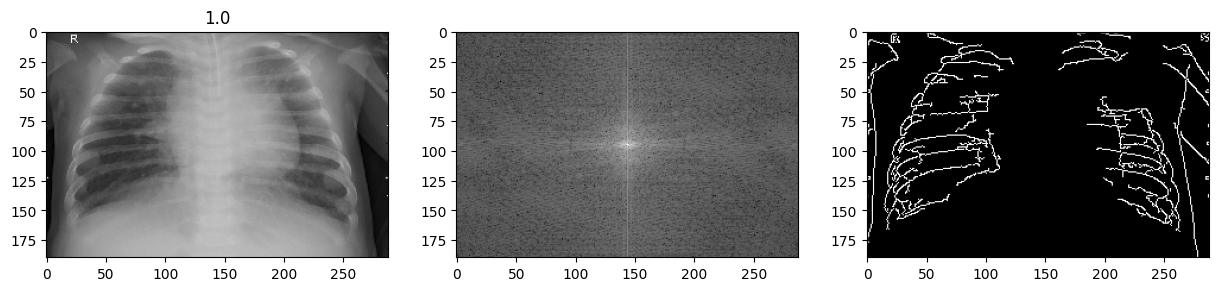

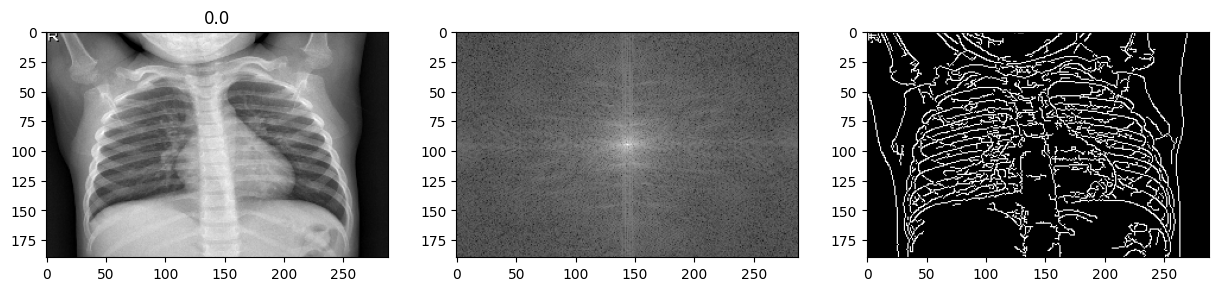

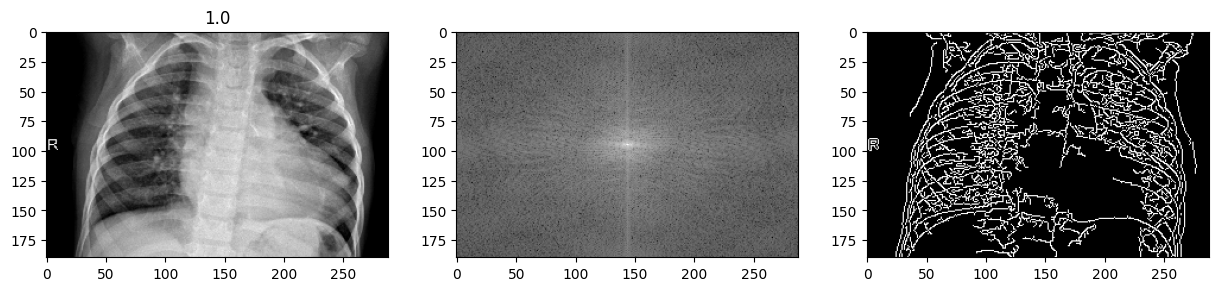

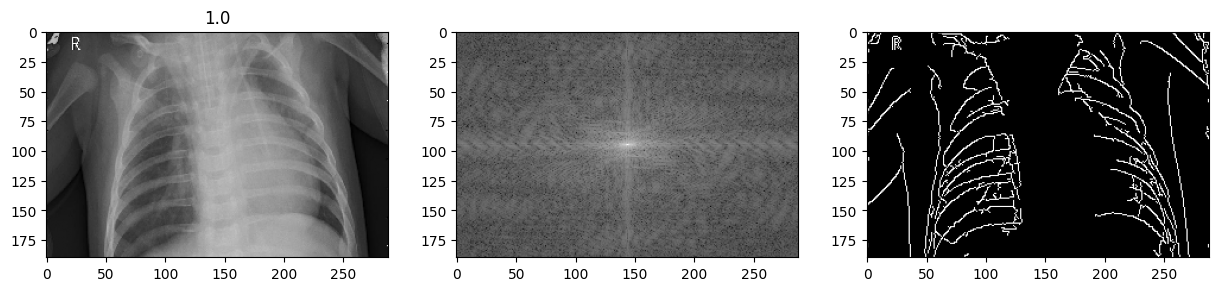

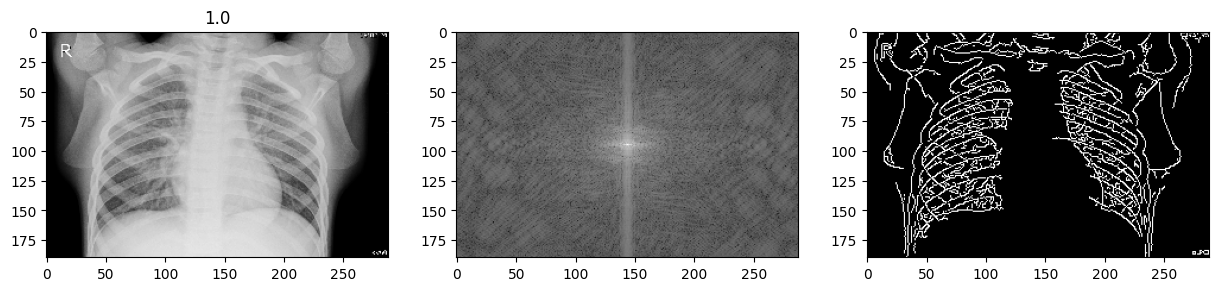

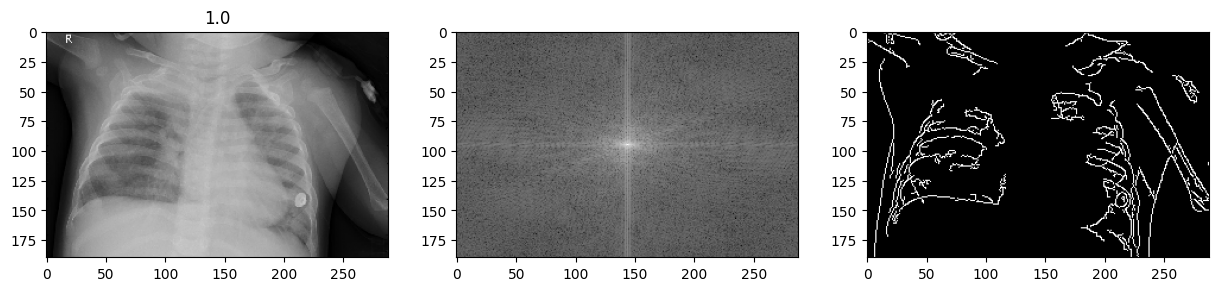

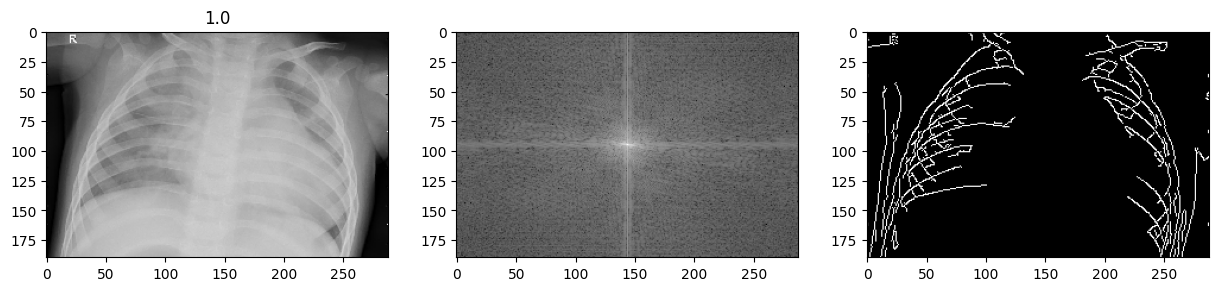

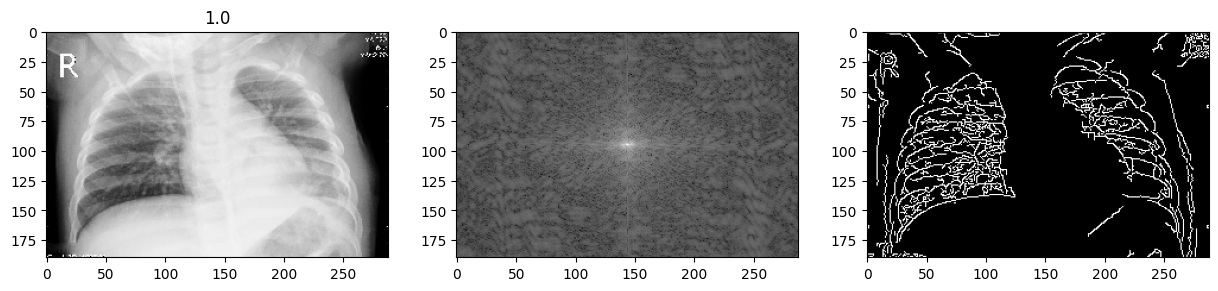

In [ ]:
batch_size = train_data.batch_size
x, y = next( train_data )

for j in range( batch_size ):
    image = x[j]
    plt.figure( figsize= (15, 5))
    plt.subplot( 1, 3, 1)
    plt.title(y[j])
    plt.imshow( image[:, :,  0], cmap='gray')
    plt.subplot( 1, 3, 2)
    plt.imshow( image[:, :,  1], cmap='gray')
    plt.subplot( 1, 3, 3)
    plt.imshow( image[:, :,  2], cmap='gray')
    plt.show()

In [ ]:
def my_preprocessing(image):
    import cv2
    import numpy as np
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Ensure grayscale image is uint8 for Canny
    gray_uint8 = gray.astype(np.uint8)
    # hist eq 추가 가능
    sobel = Sobel_edge( gray_uint8)
    canny = Canny_edge( gray_uint8)
    mag = FFT_2D( gray_uint8)

    sobel = Sobel_edge( image)
    canny = Canny_edge( image)
    mag = FFT_2D( image)
    dst = np.stack([gray, sobel, mag,  canny], axis = -1)
    return dst

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/data/'

Mounted at /content/drive


In [ ]:
import os
import cv2
# 경로 설정
base_path = path + '/chest_xray/train'

# 클래스 폴더 목록
class_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print( class_folders)

# 클래스별로  이미지 추출

train_dataset ={"images":[], "class":[]}


for class_id, class_name in enumerate(class_folders):
    folder_path = os.path.join(base_path, class_name)
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg', '.png'))]

    for fname in all_files:
        img_path = os.path.join(folder_path, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img,  (288, 190) )
        img =  my_preprocessing(img)
        train_dataset["images"].append(img)
        train_dataset["class"].append(class_name)
else:
    print(f'총 {len(class_folders)}개의 클래스, {len(train_dataset["images"])}개의 이미지를 불러왔습니다.')
    train_dataset["images"] = np.array(train_dataset["images"])
    train_dataset["class"] = np.array(train_dataset["class"])
    print( train_dataset["images"].shape, train_dataset["class"].shape)

['PNEUMONIA', 'NORMAL']
총 2개의 클래스, 5216개의 이미지를 불러왔습니다.
(5216, 190, 288, 4) (5216,)


 데이터 저장 완료: chest_x_ray_train_dataset.pkl
 불러온 데이터: (5216, 190, 288, 4)


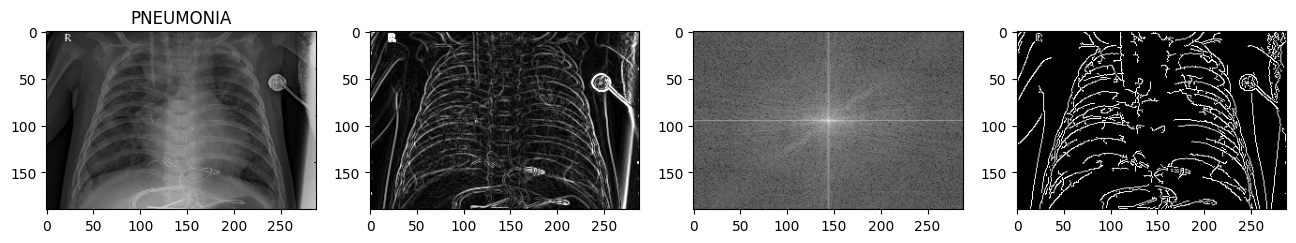

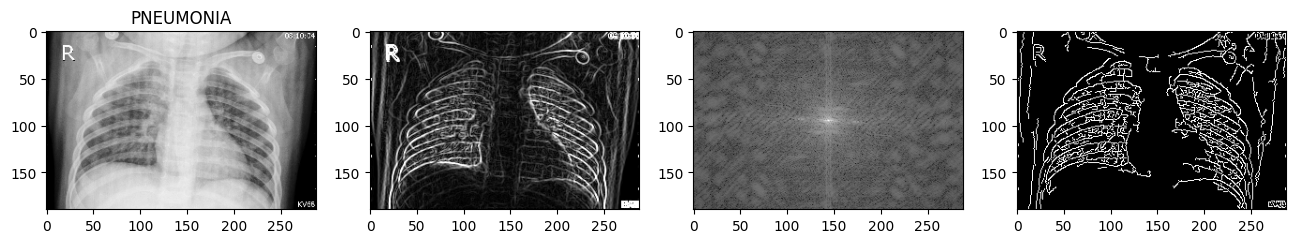

In [ ]:
import pickle

#  1. pickle로 저장하기
with open(PATH+'chest_x_ray_train_dataset.pkl', 'wb') as f:
    pickle.dump(train_dataset, f)

print(" 데이터 저장 완료: chest_x_ray_train_dataset.pkl")

#  2. pickle로 부터 불러오기
with open(PATH+'chest_x_ray_train_dataset.pkl', 'rb') as f:
    train_dataset = pickle.load(f)

print(" 불러온 데이터:", train_dataset["images"].shape)
for j  in [ 0, 1]:
    image = train_dataset["images"][j]
    plt.figure( figsize= (16, 4))
    plt.subplot( 1, 4, 1)
    plt.title(train_dataset["class"][j])
    plt.imshow( image[:, :, 0], cmap='gray')
    plt.subplot( 1, 4, 2)
    plt.imshow( image[:, :, 1], cmap='gray')
    plt.subplot( 1, 4, 3)
    plt.imshow( image[:, :, 2], cmap='gray')
    plt.subplot( 1, 4, 4)
    plt.imshow( image[:, :, 3], cmap='gray')
    plt.show()

- 테스트 데이터 셋
- base_path = path + '/chest_xray/train' 을
- base_path = path + '/chest_xray/test' 로 변경하여
- 수행한다.

In [ ]:
import os
import cv2
# 경로 설정
base_path = path + '/chest_xray/test'

# 클래스 폴더 목록
class_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print( class_folders)

# 클래스별로  이미지 추출

test_dataset ={"images":[], "class":[]}


for class_id, class_name in enumerate(class_folders):
    folder_path = os.path.join(base_path, class_name)
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg', '.png'))]

    for fname in all_files:
        img_path = os.path.join(folder_path, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img,  (288, 190) )
        img =  my_preprocessing(img)
        test_dataset["images"].append(img)
        test_dataset["class"].append(class_name)
else:
    print(f'총 {len(class_folders)}개의 클래스, {len(test_dataset["images"])}개의 이미지를 불러왔습니다.')
    test_dataset["images"] = np.array(test_dataset["images"])
    test_dataset["class"] = np.array(test_dataset["class"])
    print( test_dataset["images"].shape, test_dataset["class"].shape)

['PNEUMONIA', 'NORMAL']
총 2개의 클래스, 624개의 이미지를 불러왔습니다.
(624, 190, 288, 4) (624,)


 데이터 저장 완료: chest_x_ray_test_dataset.pkl
 불러온 데이터: (624, 190, 288, 4)


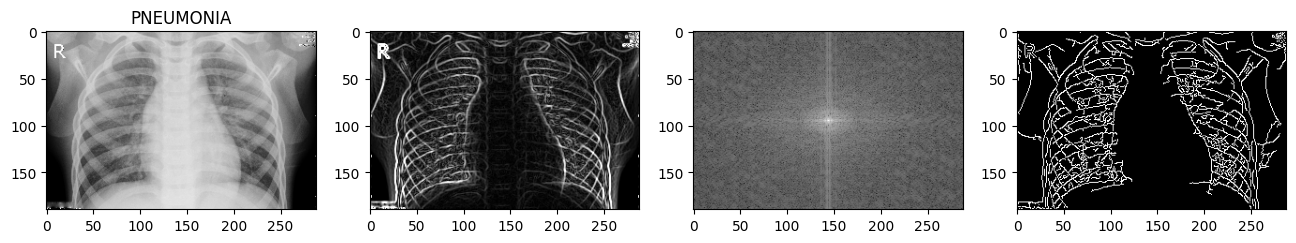

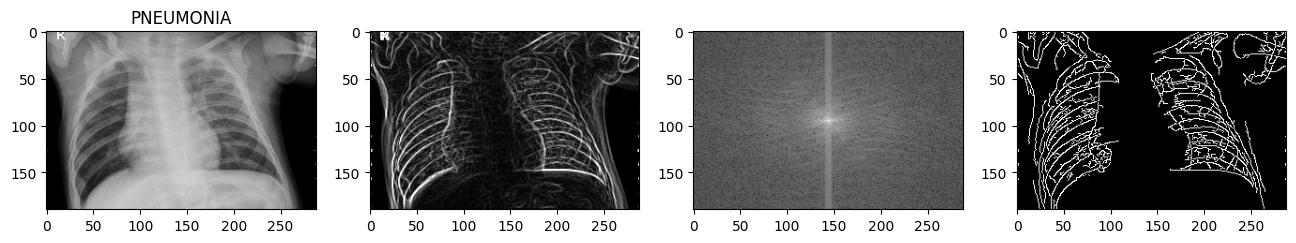

In [ ]:
import pickle

#  1. pickle로 저장하기
with open(PATH+'chest_x_ray_test_dataset.pkl', 'wb') as f:
    pickle.dump(test_dataset, f)

print(" 데이터 저장 완료: chest_x_ray_test_dataset.pkl")

#  2. pickle로 부터 불러오기
with open(PATH+'chest_x_ray_test_dataset.pkl', 'rb') as f:
    test_dataset = pickle.load(f)

print(" 불러온 데이터:", test_dataset["images"].shape)
for j  in [ 0, 1]:
    image = test_dataset["images"][j]
    plt.figure( figsize= (16, 4))
    plt.subplot( 1, 4, 1)
    plt.title(test_dataset["class"][j])
    plt.imshow( image[:, :, 0], cmap='gray')
    plt.subplot( 1, 4, 2)
    plt.imshow( image[:, :, 1], cmap='gray')
    plt.subplot( 1, 4, 3)
    plt.imshow( image[:, :, 2], cmap='gray')
    plt.subplot( 1, 4, 4)
    plt.imshow( image[:, :, 3], cmap='gray')
    plt.show()

In [1]:
%%time
import pickle
import numpy as np
import pandas as pd
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

PATH = '/content/drive/MyDrive/data/'

# ✅ 1. pickle에서 데이터 불러오기
with open(PATH+'chest_x_ray_train_dataset.pkl', 'rb') as f:
    train_dataset = pickle.load(f)

with open(PATH+'chest_x_ray_test_dataset.pkl', 'rb') as f:
    test_dataset = pickle.load(f)

print(train_dataset["images"].shape, test_dataset["images"].shape )

chn = 2
  # -> [:,:,:,0]: original, [:,:,:,1]: Sobel, [:,:,:,2]:2DFFT, [:,:,:,3]: Canny
X_train = train_dataset["images"] [:,:,:,chn]    # shape: (5216, 288, 190)
X_test = test_dataset["images"] [:,:,:,chn]

y_train_labels = train_dataset["class"]      # 'NORMAL' or 'PNEUMONIA'
y_test_labels = test_dataset["class"]

print(X_train.shape, X_test.shape, y_train_labels.shape, y_test_labels.shape )

# ✅ 2. 이미지 정규화 (영상 값 0~255 → 0~1)
X_train  = (X_train  / 255.0).astype(np.float16)
X_test = (X_test / 255.0).astype(np.float16)

# ✅ 3. 벡터 변환 (flatten)
X_train = X_train.reshape(X_train.shape[0], -1)  # shape: (5216, 54720)
X_test = X_test.reshape(X_test.shape[0], -1)
print('->',X_train.shape, X_test.shape, y_train_labels.shape, y_test_labels.shape )

# ✅ 4. 클래스 라벨 인코딩
le = LabelEncoder()
y_train = le.fit_transform(y_train_labels)  # 'NORMAL' → 0, 'PNEUMONIA' → 1
y_test = le.transform(y_test_labels)

(5216, 190, 288, 4) (624, 190, 288, 4)
(5216, 190, 288) (624, 190, 288) (5216,) (624,)
-> (5216, 54720) (624, 54720) (5216,) (624,)
CPU times: user 4.73 s, sys: 3.87 s, total: 8.6 s
Wall time: 45.4 s


In [2]:
%whos

Variable           Type              Data/Info
----------------------------------------------
LabelEncoder       type              <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
PATH               str               /content/drive/MyDrive/data/
X_test             ndarray           624x54720: 34145280 elems, type `float16`, 68290560 bytes (65.126953125 Mb)
X_train            ndarray           5216x54720: 285419520 elems, type `float16`, 570839040 bytes (544.39453125 Mb)
chn                int               2
datetime           type              <class 'datetime.datetime'>
f                  BufferedReader    <_io.BufferedReader name=<...>_x_ray_test_dataset.pkl'>
le                 LabelEncoder      LabelEncoder()
np                 module            <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pd                 module            <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
pickle             module            <module 'pickle' from '/u<...>ib/python3.12/pi

In [2]:
del train_dataset, test_dataset

In [ ]:
%%time
import pickle
import numpy as np
import pandas as pd
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from pprint import pprint


# ✅ 6. 분류기 정의
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "kNN": KNeighborsClassifier(n_neighbors=5),
   "SVM": SVC(kernel='linear'), # --> kernel = linear?? sigmoid(성능 낮음)
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
#    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# ✅ 7. 성능 평가 저장소
results = []

# ✅ 8. 분류 및 성능 평가
for name, clf in classifiers.items():
    print( f"{name} 모델 학습 중...", end=" ")
    start_time = datetime.now()
    print("시작 시간:", start_time.strftime("%Y-%m-%d %H:%M:%S"))
    clf.fit(X_train, y_train)
    end_time = datetime.now()
    print("종료 시간:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
    # 시간 차이 계산 (분 단위로 출력)
    elapsed_time = end_time - start_time
    elapsed_minutes = elapsed_time.total_seconds() / 60
    print(f"실행 시간 차이: {elapsed_minutes:.2f} 분")

    print("테스트...", end=" ")
    y_pred = clf.predict(X_test)
    print("성능 ..",  end="\n")
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    pprint( results)
else:
    print("✅ 분류 및 성능 평가 완료!")

# ✅ 9. 성능 비교 출력
df_results = pd.DataFrame(results)
print("\n📊 분류 성능 비교:")
print(df_results.sort_values("F1 Score", ascending=False))

# ✅ 10. pickle로 저장하기
with open(PATH+'chest_x_ray_classification_fulldataset_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✅ 데이터 저장 완료: chest_x_ray_classification_fulldataset_results.pkl")


Logistic Regression 모델 학습 중... 시작 시간: 2025-09-02 05:30:45
종료 시간: 2025-09-02 05:31:23
실행 시간 차이: 0.64 분
테스트... 성능 ..
[{'Accuracy': 0.7003205128205128,
  'F1 Score': 0.8021164021164021,
  'Model': 'Logistic Regression',
  'Precision': 0.6828828828828829,
  'Recall': 0.9717948717948718}]
kNN 모델 학습 중... 시작 시간: 2025-09-02 05:31:24
종료 시간: 2025-09-02 05:31:27
실행 시간 차이: 0.05 분
테스트... 성능 ..
[{'Accuracy': 0.7003205128205128,
  'F1 Score': 0.8021164021164021,
  'Model': 'Logistic Regression',
  'Precision': 0.6828828828828829,
  'Recall': 0.9717948717948718},
 {'Accuracy': 0.6282051282051282,
  'F1 Score': 0.7675350701402806,
  'Model': 'kNN',
  'Precision': 0.6299342105263158,
  'Recall': 0.982051282051282}]
SVM 모델 학습 중... 시작 시간: 2025-09-02 05:31:47
종료 시간: 2025-09-02 05:45:51
실행 시간 차이: 14.07 분
테스트... 성능 ..
[{'Accuracy': 0.7003205128205128,
  'F1 Score': 0.8021164021164021,
  'Model': 'Logistic Regression',
  'Precision': 0.6828828828828829,
  'Recall': 0.9717948717948718},
 {'Accuracy': 0.6282051

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC 곡선 색상 및 스타일 정의
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    # 확률 예측 또는 decision function
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    else:
        y_score = clf.decision_function(X_test)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # 곡선 그리기
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# 대각선 기준선
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

# 그래프 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves of Classifiers')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 혼동 행렬 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, clf) in zip(axes, classifiers.items()):
    # 예측
    y_pred = clf.predict(X_test)

    # 혼동 행렬 계산
    cm = confusion_matrix(y_test, y_pred)

    # 시각화
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Ground Truth")

plt.tight_layout()
plt.show()

In [ ]:
PATH = "./"

In [4]:
import pickle
import numpy as np
import pandas as pd
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from pprint import pprint

# pickle로 저장된 결과 파일 로드
with open(PATH+'chest_x_ray_classification_fulldataset_results.pkl', 'rb') as f:
    results = pickle.load(f)

print("데이터 로드 완료: chest_x_ray_classification_fulldataset_results.pkl")

# ✅ 6. 분류기 정의
classifiers = {}
classifiers["XGBoost"] =  xgb.XGBClassifier(use_label_encoder=False,
                                            eval_metric='logloss')

# ✅ 8. 분류 및 성능 평가
cls = [("XGBoost", classifiers["XGBoost"])]

for name, clf in classifiers.items():
    print( f"{name} 모델 학습 중...", end=" ")
    start_time = datetime.now()
    print("시작 시간:", start_time.strftime("%Y-%m-%d %H:%M:%S"))
    clf.fit(X_train, y_train)
    end_time = datetime.now()
    print("종료 시간:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
    # 시간 차이 계산 (분 단위로 출력)
    elapsed_time = end_time - start_time
    elapsed_minutes = elapsed_time.total_seconds() / 60
    print(f"실행 시간 차이: {elapsed_minutes:.2f} 분")

    print("테스트...", end=" ")
    y_pred = clf.predict(X_test)
    print("성능 ..",  end="\n")
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    pprint( results)
else:
    print("✅ 분류 및 성능 평가 완료!")

# ✅ 9. 성능 비교 출력
df_results = pd.DataFrame(results)
print("\n📊 분류 성능 비교:")
print(df_results.sort_values("F1 Score", ascending=False))

# ✅ 10. pickle로 저장하기
with open(PATH+'chest_x_ray_classification_fulldataset_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✅ 데이터 저장 완료: chest_x_ray_classification_fulldataset_results.pkl")


NameError: name 'PATH' is not defined

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC 곡선 색상 및 스타일 정의
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    # 확률 예측 또는 decision function
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    else:
        y_score = clf.decision_function(X_test)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # 곡선 그리기
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# 대각선 기준선
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

# 그래프 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves of Classifiers')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 혼동 행렬 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, clf) in zip(axes, classifiers.items()):
    # 예측
    y_pred = clf.predict(X_test)

    # 혼동 행렬 계산
    cm = confusion_matrix(y_test, y_pred)

    # 시각화
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Ground Truth")

plt.tight_layout()
plt.show()